# Modelling: Predicting Diabetes Risk (BRFSS 2015)
Goal: rank indicators and build a risk score an insurer could use for premium tiers. Y is imbalanced (~16% positive), so we use stratified splits, class weights, PR-AUC, threshold tuning and a calibration check.

## Plain-English glossary
| Term | Meaning |
|---|---|
| **Y / "at risk"** | The thing we predict: whether a respondent has **diabetes or prediabetes** (about 16% of people). |
| **Indicator / question** | One survey answer, e.g. high blood pressure, BMI, age. |
| **Rate (%)** | Out of 100 people in a group, how many have diabetes/prediabetes. |
| **Correlation** | A number from -1 to +1 showing how consistently two things move together. It shows association, **not** cause. |
| **Model** | A formula learned from past survey answers that gives each person a **risk score** between 0 and 1. |
| **Training / validation / test data** | Training = data the model learns from. Validation = used to tune settings. Test = data the model has never seen, used for the honest final grade. |
| **AUC (ROC-AUC)** | How well the model ranks risky people above safe ones. 0.5 = coin flip, 1.0 = perfect. ~0.82 here = decent, not perfect. |
| **PR-AUC** | Like AUC but stricter when the group we look for is rare. Random guessing scores about 0.16 (the share of at-risk people). |
| **Recall** | Of all people who really have diabetes, the share the model catches. |
| **Precision** | Of all people the model flags as high-risk, the share who really have diabetes. |
| **Threshold** | The cut-off score above which we call someone "high risk". Lower it: catch more diabetics but more false alarms. |
| **Imbalance** | Only ~16% of people are at risk, so a model saying "nobody has diabetes" is 84% accurate yet useless. We therefore don't judge on accuracy. |
| **Class weights / SMOTE** | Two ways to stop the model ignoring the rare group: weights make mistakes on at-risk people count more; SMOTE creates synthetic extra at-risk examples (training data only). |
| **Calibration** | Whether a predicted 20% risk really means about 20 in 100 people get diabetes. Needed before a score can set a price. |
| **Feature importance** | How much the model's accuracy drops if one question is scrambled. Big drop = the model relies on it. |


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             roc_curve, confusion_matrix, classification_report)
sns.set_theme(style='whitegrid'); SEED=0
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
y = (df.Diabetes_012 > 0).astype(int); X = df.drop(columns='Diabetes_012')
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
print(Xtr.shape, Xte.shape, 'positive rate train/test:', ytr.mean().round(4), yte.mean().round(4))

(190260, 21) (63420, 21) positive rate train/test: 0.1576 0.1576


## 1. Baselines vs. class-weighted models (5-fold stratified CV on train)
A dummy 'always no diabetes' model shows why accuracy misleads.

In [2]:
from sklearn.dummy import DummyClassifier
models = {
 'Dummy (majority)': DummyClassifier(strategy='most_frequent'),
 'LogReg (balanced)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced')),
 'RandomForest (balanced)': RandomForestClassifier(n_estimators=200, min_samples_leaf=50, class_weight='balanced_subsample', n_jobs=-1, random_state=SEED),
 'HistGB (balanced)': HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof, rows = {}, []
for n, m in models.items():
    p = cross_val_predict(m, Xtr, ytr, cv=cv, method='predict_proba')[:,1] if n!='Dummy (majority)' else np.zeros(len(ytr))
    oof[n] = p
    acc = ((p>0.5)==ytr).mean()
    rows.append((n, acc, roc_auc_score(ytr,p) if p.std()>0 else 0.5, average_precision_score(ytr,p)))
res = pd.DataFrame(rows, columns=['model','accuracy@0.5','ROC-AUC','PR-AUC']).set_index('model').round(3)
res

,accuracy@0.5,ROC-AUC,PR-AUC
model,,,
Dummy (majority),0.842,0.500,0.158
LogReg (balanced),0.728,0.816,0.429
RandomForest (balanced),0.726,0.821,0.455
HistGB (balanced),0.718,0.823,0.457


**Conclusion:** The dummy model gets ~84% accuracy with zero skill (PR-AUC equals the base rate). Compare models on ROC-AUC/PR-AUC instead; the balanced models' accuracy is lower precisely because they flag more diabetics.

## 2. Hold-out test performance of the best model
Note: this notebook uses a plain random split, so identical answer profiles (9.4% duplicate rows) can land in both train and test and slightly inflate scores. `MODEL2` and `FINAL` split by answer profile (AUC 0.824 vs 0.828 here).

> **How to read the chart below**
>
> **Left, ROC curve:** the model scores everyone and we flag people from the highest score down. The curve shows, as we flag more people, how many real diabetics we catch (**up**) against how many healthy people we wrongly flag (**right**). The dashed diagonal is random guessing. The more the curve bows toward the top-left, the better. **AUC** is the area under it: 0.5 = coin flip, 1.0 = perfect.
> **Right, Precision-Recall curve:** *recall* = share of all diabetics caught; *precision* = share of flagged people who truly have diabetes. The dashed line is what random flagging would give (about 16%).
> **What to notice:** the curve sits above the dashed lines (the model has skill), but precision falls as recall rises: catching more diabetics means more false alarms.

Best by PR-AUC: HistGB (balanced)


Test ROC-AUC 0.828 | PR-AUC 0.464 | base rate 0.158


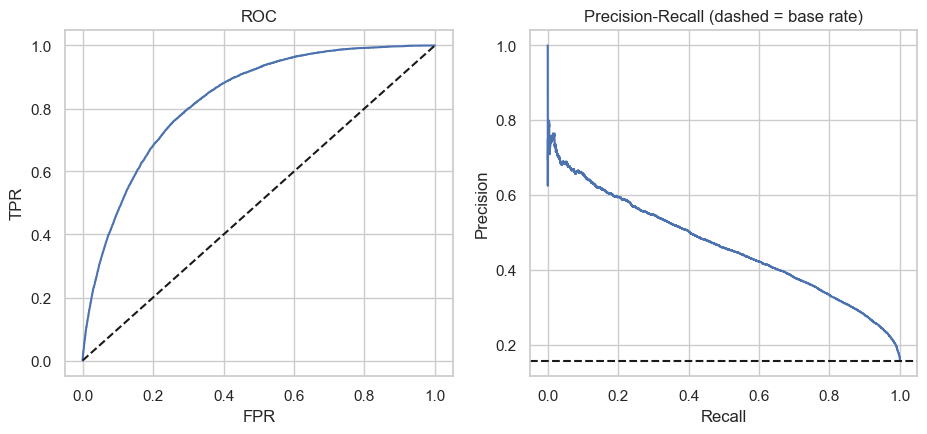

In [3]:
best = res['PR-AUC'].drop('Dummy (majority)').idxmax(); print('Best by PR-AUC:', best)
m = models[best].fit(Xtr, ytr); pte = m.predict_proba(Xte)[:,1]
print('Test ROC-AUC', round(roc_auc_score(yte,pte),3), '| PR-AUC', round(average_precision_score(yte,pte),3), '| base rate', round(yte.mean(),3))
fig, ax = plt.subplots(1,2, figsize=(11,4.5))
fpr,tpr,_ = roc_curve(yte,pte); ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],'k--'); ax[0].set(title='ROC', xlabel='FPR', ylabel='TPR')
pr,rc,_ = precision_recall_curve(yte,pte); ax[1].plot(rc,pr); ax[1].axhline(yte.mean(), ls='--', c='k'); ax[1].set(title='Precision-Recall (dashed = base rate)', xlabel='Recall', ylabel='Precision')
plt.show()

**Conclusion:** The model clearly beats chance (ROC-AUC ~0.82) but precision falls quickly as recall rises: diabetes is only moderately predictable from survey answers, so the model is a risk-tiering tool, not a diagnosis.

## 3. Threshold tuning from a business cost
**Assumption (change it):** wrongly treating a diabetic as low-risk costs 5x as much as wrongly loading a healthy person. Threshold is picked on out-of-fold train predictions, then applied once to test.

> **How to read the chart below**
>
> **Left, cost vs threshold:** each person gets a risk score. The *threshold* is the cut-off for calling someone 'high risk'. We *assume* missing a diabetic costs 5 and a false alarm costs 1. The curve is total cost at each cut-off, and the **red dashed line marks the cheapest cut-off**.
> **Right, confusion matrix:** a 2x2 scorecard on the test data. Rows = the truth, columns = the model's call. **Top-left** = healthy people correctly cleared. **Bottom-right** = diabetics correctly flagged. **Top-right** = false alarms (healthy but flagged). **Bottom-left** = missed diabetics.

Chosen threshold: 0.5


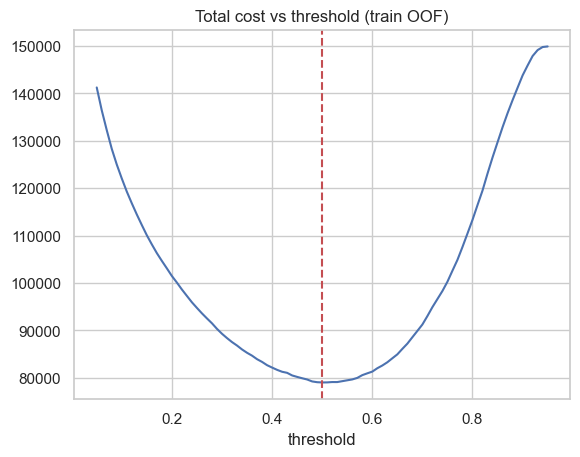

              precision    recall  f1-score   support

 No diabetes      0.949     0.702     0.807     53426
Diabetes/Pre      0.334     0.799     0.471      9994

    accuracy                          0.717     63420
   macro avg      0.642     0.750     0.639     63420
weighted avg      0.852     0.717     0.754     63420



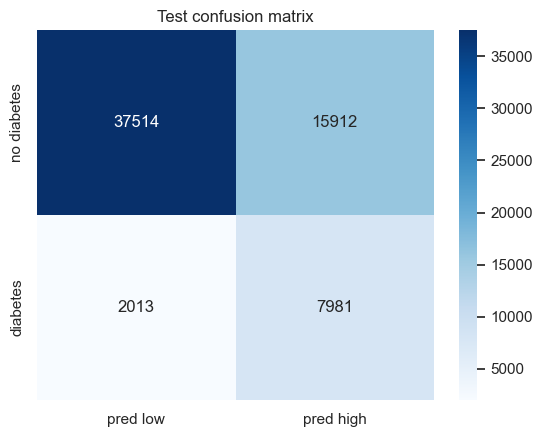

Test cost: 25977 | cost if everyone treated low-risk: 49970


In [4]:
COST_FN, COST_FP = 5, 1
p_oof = oof[best]
ths = np.linspace(0.05, 0.95, 91)
cost = [COST_FN*((p_oof<t)&(ytr==1)).sum() + COST_FP*((p_oof>=t)&(ytr==0)).sum() for t in ths]
t_star = ths[int(np.argmin(cost))]; print('Chosen threshold:', round(t_star,2))
plt.plot(ths, cost); plt.axvline(t_star, c='r', ls='--'); plt.title('Total cost vs threshold (train OOF)'); plt.xlabel('threshold'); plt.show()
pred = (pte>=t_star).astype(int)
print(classification_report(yte, pred, target_names=['No diabetes','Diabetes/Pre'], digits=3))
cm = confusion_matrix(yte, pred); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pred low','pred high'], yticklabels=['no diabetes','diabetes']); plt.title('Test confusion matrix'); plt.show()
print('Test cost:', COST_FN*cm[1,0] + COST_FP*cm[0,1], '| cost if everyone treated low-risk:', COST_FN*yte.sum())

**Conclusion:** The cost-optimal threshold is 0.5, the same as the default, because `class_weight='balanced'` already encodes roughly a 5:1 cost for misses. At that threshold the model catches 80% of diabetics with 33% precision, and halves the assumed cost (26k vs 50k for treating everyone as low-risk). The result depends on the assumed 5:1 ratio, which should come from actuarial claims data.

## 4. Calibration: are predicted probabilities real risks?
Class weights inflate probabilities. A premium needs a true risk estimate, so we recalibrate (isotonic) and compare.

> **How to read the chart below**
>
> **Do the predicted risks match reality?** People are sorted into 10 equal groups from lowest to highest predicted risk. For each group, the **horizontal axis** is the average risk the model *predicted* and the **vertical axis** is the share who *actually* had diabetes. Points on the **dashed diagonal** mean honest probabilities.
> **What to notice:** the raw (red) points sit well below the diagonal: the model exaggerates risk because we trained it to be extra sensitive. After recalibration (blue) they sit on the line. A premium needs an honest probability, so we use the calibrated version.

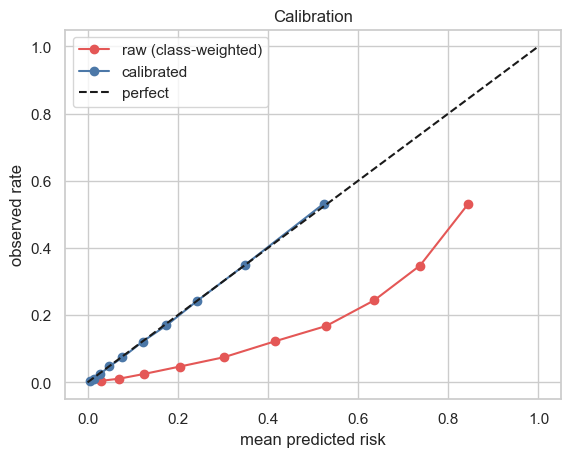

Mean predicted risk | raw 0.390 | calibrated 0.158 | actual 0.158
ROC-AUC calibrated: 0.828


In [5]:
import sklearn.base as skb
cal = CalibratedClassifierCV(skb.clone(models[best]), method='isotonic', cv=5).fit(Xtr, ytr)
pcal = cal.predict_proba(Xte)[:,1]
for lbl,p,col in [('raw (class-weighted)',pte,'#e45756'),('calibrated',pcal,'#4c78a8')]:
    fx,fy = calibration_curve(yte,p,n_bins=10,strategy='quantile'); plt.plot(fy,fx,marker='o',label=lbl,color=col)
plt.plot([0,1],[0,1],'k--',label='perfect'); plt.xlabel('mean predicted risk'); plt.ylabel('observed rate'); plt.legend(); plt.title('Calibration'); plt.show()
print('Mean predicted risk | raw %.3f | calibrated %.3f | actual %.3f' % (pte.mean(), pcal.mean(), yte.mean()))
print('ROC-AUC calibrated:', round(roc_auc_score(yte,pcal),3))

**Conclusion:** Raw class-weighted scores over-predict risk (mean 0.39 vs actual 0.16); calibrated scores match (0.158). Ranking (AUC) is unchanged, so use calibrated probabilities when turning risk into a premium.

## 5. Which indicators matter? (premium drivers)

> **How to read the chart below**
>
> **Feature importance:** we scramble one question's answers and see how much accuracy falls. A **long bar = the model relies heavily on that question**. The printed table (odds ratios) says how much the odds of diabetes change when a question rises by a typical step; above 1 raises risk, below 1 lowers it.

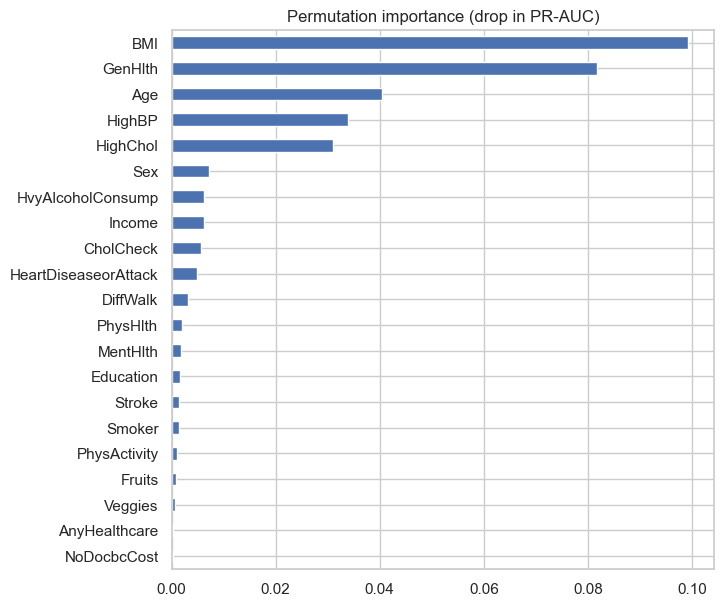

Odds ratio per +1 SD (logistic regression):
HvyAlcoholConsump       0.86
Income                  0.88
PhysHlth                0.95
Education               0.96
Fruits                  0.97
MentHlth                0.97
PhysActivity            0.97
Veggies                 0.98
Smoker                  1.00
AnyHealthcare           1.00
NoDocbcCost             1.03
DiffWalk                1.03
Stroke                  1.03
HeartDiseaseorAttack    1.07
Sex                     1.14
CholCheck               1.26
HighChol                1.34
HighBP                  1.40
Age                     1.58
BMI                     1.62
GenHlth                 1.79


In [6]:
ix = Xtr.sample(40000, random_state=SEED).index  # rank on TRAIN data so the test set stays untouched for the short-form check
imp = permutation_importance(m, Xtr.loc[ix], ytr.loc[ix], scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(imp.importances_mean, X.columns).sort_values()
imp.plot.barh(figsize=(7,7), title='Permutation importance (drop in PR-AUC)'); plt.show()
lr = models['LogReg (balanced)'].fit(Xtr, ytr)
odds = pd.Series(np.exp(lr[-1].coef_[0]), X.columns).sort_values()
print('Odds ratio per +1 SD (logistic regression):'); print(odds.round(2).to_string())

**Conclusion:** GenHlth, BMI, Age, HighBP and HighChol drive predictions (largest odds ratios). GenHlth is partly a consequence of illness, and Age/Income/Sex are sensitive for pricing, so the defensible, actionable drivers are the medical ones (BP, cholesterol, BMI).

## 6. Short-form questionnaire
Rank-based forward selection would be heavy; instead take the top-k by importance, excluding CholCheck (likely an artefact: people never checked rarely have a diagnosis).

> **How to read the chart below**
>
> A line of model accuracy (**AUC**, vertical) as we allow the model only its top **k questions** (horizontal). **What to notice:** where the line flattens, extra questions add almost nothing, so a short questionnaire can work. (We left out CholCheck because it is a quirk, not a real risk factor.)

 n features  ROC-AUC  PR-AUC  last added
          3    0.803   0.416         Age
          5    0.820   0.451    HighChol
          6    0.822   0.453         Sex
          8    0.825   0.458      Income
         10    0.826   0.460    DiffWalk
         15    0.827   0.463      Smoker
         20    0.827   0.462 NoDocbcCost


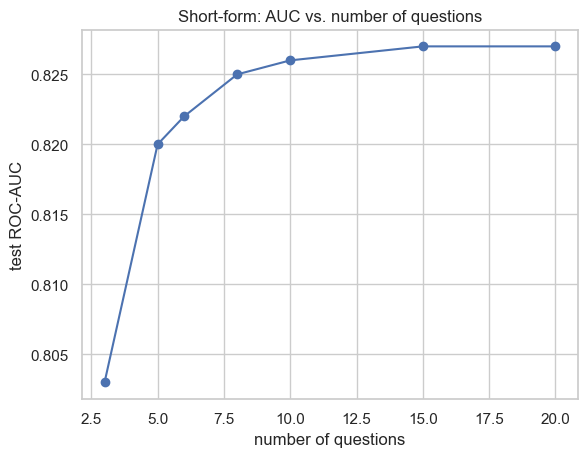

Top questions: ['BMI', 'GenHlth', 'Age', 'HighBP', 'HighChol', 'Sex', 'HvyAlcoholConsump', 'Income']


In [7]:
order = [f for f in imp.index[::-1] if f != 'CholCheck']
rows = []
for k in [3,5,6,8,10,15,len(order)]:
    cols = order[:k]
    g = HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED).fit(Xtr[cols], ytr)
    p = g.predict_proba(Xte[cols])[:,1]
    rows.append((k, roc_auc_score(yte,p), average_precision_score(yte,p), ', '.join(cols[-1:])))
sf = pd.DataFrame(rows, columns=['n features','ROC-AUC','PR-AUC','last added']).round(3); print(sf.to_string(index=False))
plt.plot(sf['n features'], sf['ROC-AUC'], marker='o'); plt.xlabel('number of questions'); plt.ylabel('test ROC-AUC'); plt.title('Short-form: AUC vs. number of questions'); plt.show()
print('Top questions:', order[:8])

**Conclusion:** 5 questions (BMI, GenHlth, Age, HighBP, HighChol) give AUC 0.820 vs 0.827 for all 20, so a short form keeps nearly all the signal. Adding Sex, heavy drinking and Income (the next three) lifts AUC by only about 0.005 combined, and Sex and Income are pricing-sensitive, so leave them out.

## 7. Summary
- Imbalance handled with stratified splits, class weights, PR-AUC, threshold tuning and calibration.
- Survey data gives moderate predictive power (ROC-AUC ~0.82); use as a risk tier, not a diagnosis.
- A short form of 5 questions (BMI, general health, age, cholesterol, blood pressure) keeps most of the signal.
- Limits: association only, self-reported, no claims/premium data; cost ratio is an assumption; Age/Income/Sex may be unusable for pricing.